In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../data/cleaned_house_prices.csv")

In [3]:
df.shape

(12744, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12744 entries, 0 to 12743
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       12744 non-null  str    
 1   availability    12744 non-null  str    
 2   location        12744 non-null  str    
 3   bhk             12744 non-null  float64
 4   society         12744 non-null  str    
 5   total_sqft      12744 non-null  float64
 6   bath            12744 non-null  float64
 7   balcony         12744 non-null  float64
 8   price           12744 non-null  float64
 9   price_per_sqft  12744 non-null  float64
dtypes: float64(6), str(4)
memory usage: 995.8 KB


In [5]:
df.describe()

,bhk,total_sqft,bath,balcony,price,price_per_sqft
count,12744.000000,12744.000000,12744.000000,12744.000000,12744.000000,1.274400e+04
mean,2.817012,1569.601295,2.703076,1.508945,114.209563,8.023104e+03
std,1.308172,1259.884333,1.352391,0.869811,151.597429,1.086177e+05
min,1.000000,1.000000,1.000000,0.000000,8.000000,2.678298e+02
25%,2.000000,1100.000000,2.000000,1.000000,50.000000,4.298543e+03
50%,3.000000,1280.000000,2.000000,2.000000,73.000000,5.482380e+03
75%,3.000000,1691.000000,3.000000,2.000000,120.000000,7.398925e+03
max,43.000000,52272.000000,40.000000,3.000000,3600.000000,1.200000e+07


In [6]:
df.describe(include="object")

C:\Users\rukun\AppData\Local\Temp\ipykernel_23752\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,area_type,availability,location,society
count,12744,12744,12744,12744
unique,4,81,1299,2687
top,Super built-up Area,Ready To Move,Whitefield,Unknown
freq,8305,10132,521,5298


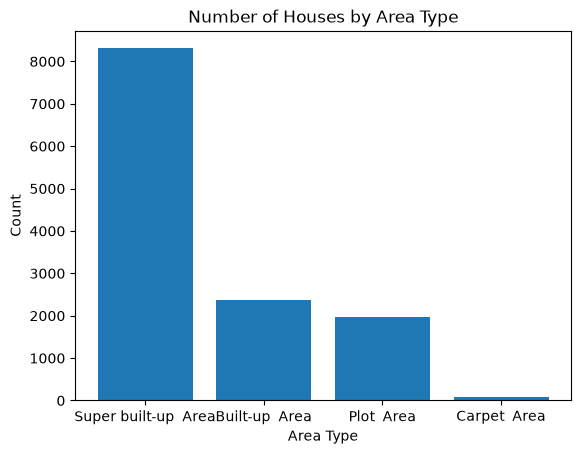

In [3]:
a=df["area_type"].value_counts()
plt.bar(a.index, a.values)
plt.title("Number of Houses by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Count")
plt.savefig("../images/num_houses_by_area_type.png", dpi=300, bbox_inches="tight")
plt.show()

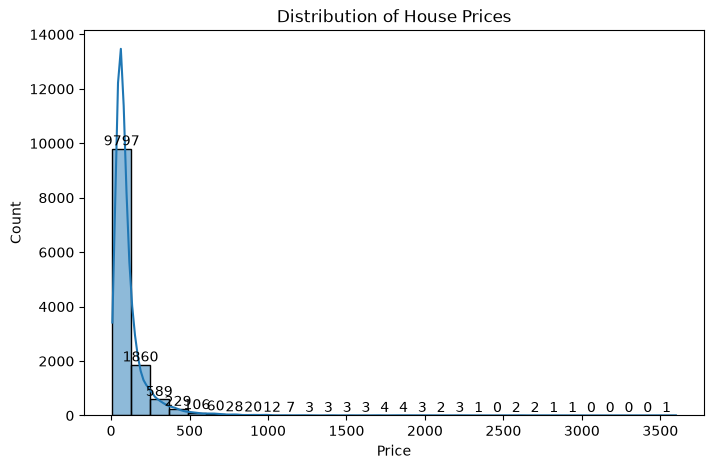

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
a=sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
for i in a.patches:
    plt.text(i.get_x() + i.get_width()/2, i.get_height() + 5, str(int(i.get_height())), ha='center', va='bottom')
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("../images/distribution_of_house_prices.png", dpi=300, bbox_inches="tight")
plt.show()

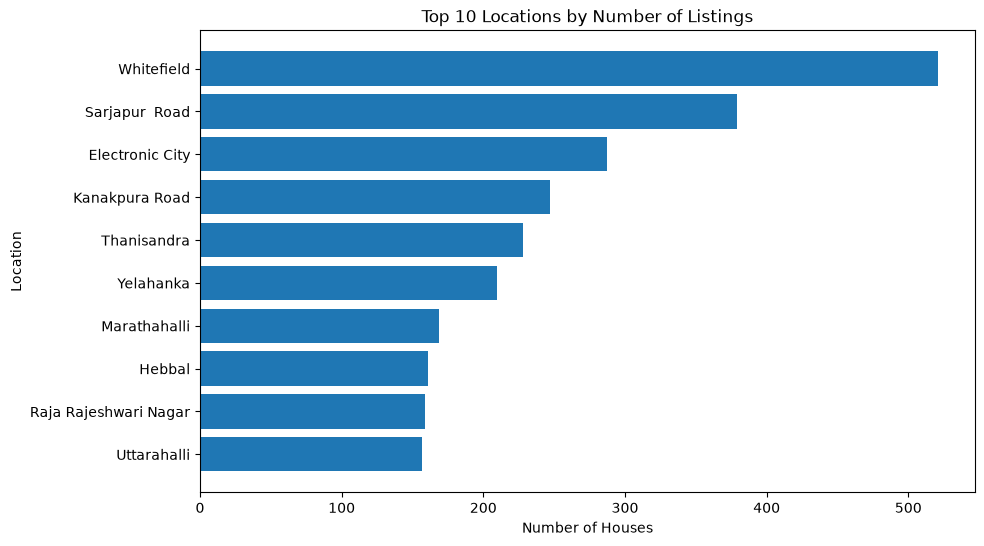

In [5]:
a = df["location"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(a.index, a.values)
plt.xlabel("Number of Houses")
plt.ylabel("Location")
plt.title("Top 10 Locations by Number of Listings")
plt.gca().invert_yaxis()  # Highest count at the top
plt.savefig("../images/top_10_locations.png", dpi=300, bbox_inches="tight")
plt.show()

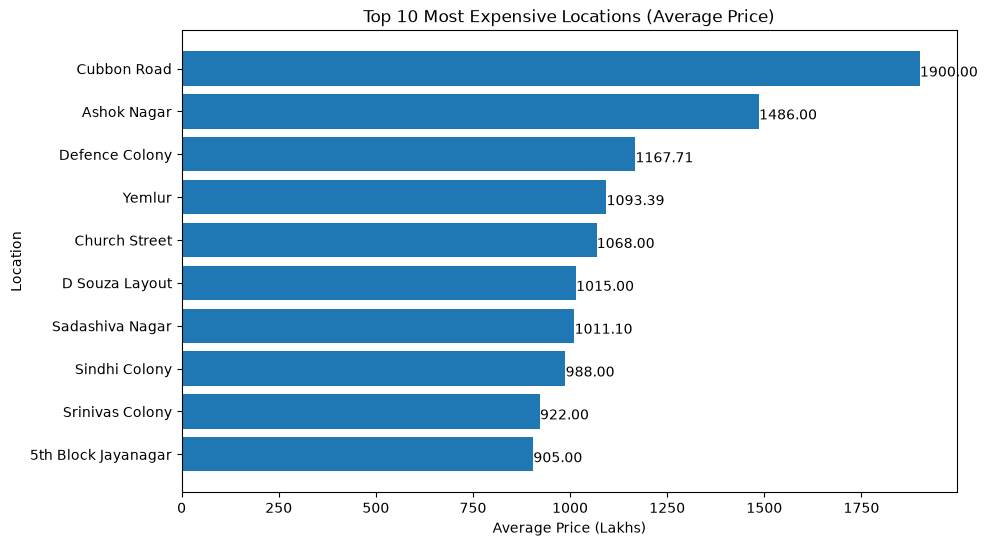

In [11]:
a = df.groupby("location")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
bar=plt.barh(a.index, a.values)
plt.xlabel("Average Price (Lakhs)")
plt.ylabel("Location")
plt.title("Top 10 Most Expensive Locations (Average Price)")
plt.gca().invert_yaxis()   # Highest price at the top
for i in bar:
    plt.text(i.get_width() + 0.5, i.get_y() + 0.5, f'{i.get_width():.2f}', va='center')
plt.savefig("../images/top_10_expensive_locations.png", dpi=300, bbox_inches="tight")
plt.show()


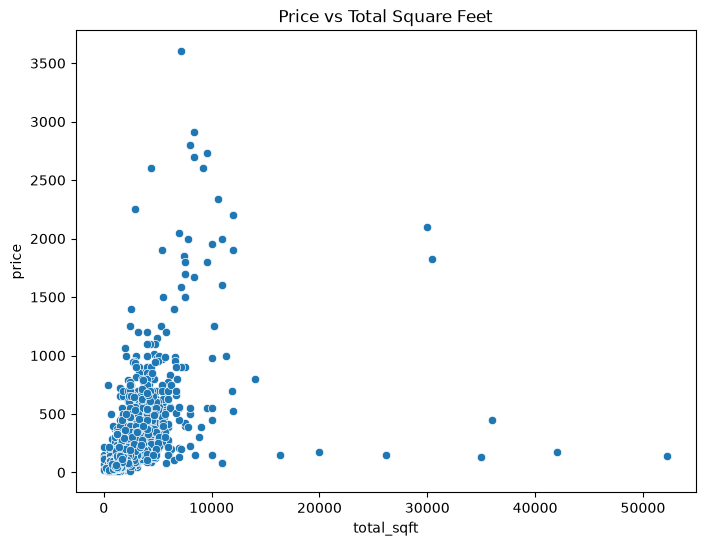

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="total_sqft", y="price")
plt.title("Price vs Total Square Feet")
plt.savefig("../images/price_vs_total_sqft.png", dpi=300, bbox_inches="tight")
plt.show()

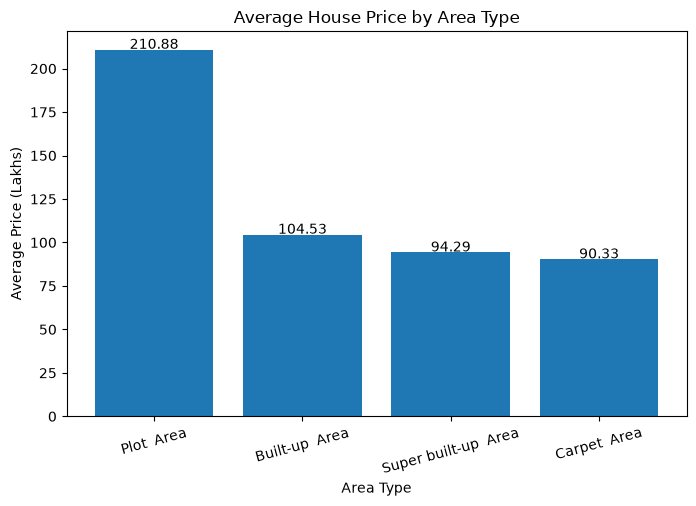

In [6]:
a=df.groupby("area_type")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
b=plt.bar(a.index, a.values)

plt.title("Average House Price by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=15)
for i in b:
    plt.text(i.get_x() + i.get_width()/2, i.get_height() + 0.5, f'{i.get_height():.2f}', ha='center')
plt.savefig("../images/average_house_price_by_area_type.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
df["availability_status"] = df["availability"].apply(
    lambda x: "Ready To Move" if x == "Ready To Move" else "Under Construction"
)


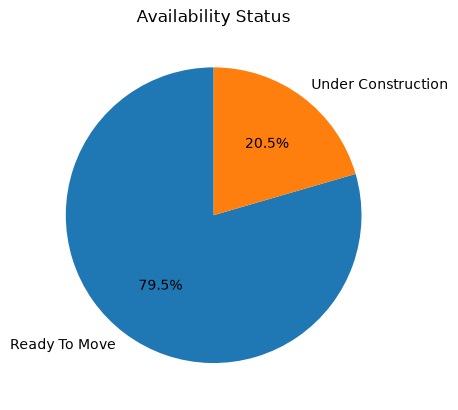

In [9]:
a = df["availability_status"].value_counts()
plt.pie(a.values, labels=a.index, autopct='%1.1f%%', startangle=90)
plt.title("Availability Status")
plt.savefig("../images/availability_status.png", dpi=300, bbox_inches="tight")
plt.show()

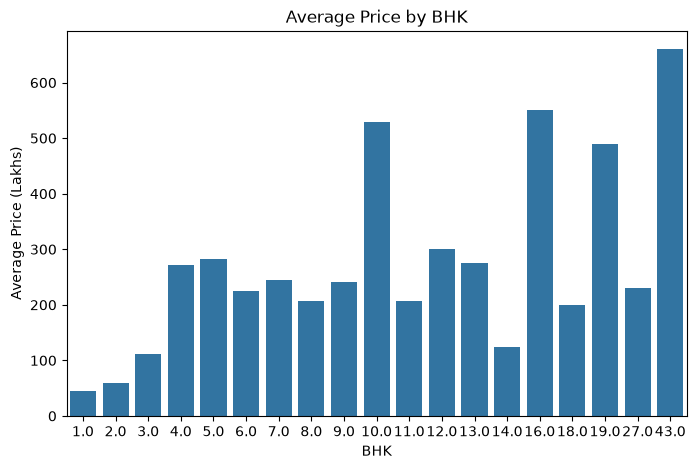

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="bhk", y="price", estimator="mean",errorbar=None)

plt.title("Average Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price (Lakhs)")
plt.savefig("../images/average_price_by_bhk.png", dpi=300, bbox_inches="tight")
plt.show()